This project is a comprehensive analysis focused on modeling renewable energy technologies to assess their profitability and sustainability, particularly in the context of future decarbonization scenarios and policies.


#Overview

The core of this work involves modeling various renewable energy technologies. It uses financial data such as Capital Expenditure (CAPEX), Operational Expenditure (OPEX), project lifetime, and estimated discount rates to predict the profitability of different technologies. Additionally, it includes a sustainability assessment that considers future decarbonization pathways and policy impacts.

#Marginal Abatement Cost Curve (MACC) Analysis



The project utilizes Marginal Abatement Cost Curves (MACC) to identify the most cost-effective ways to reduce CO2 emissions. Key elements of this analysis include:

- **Technology**: A range of renewable technologies like Solar PV, Onshore Wind, Biomass, Nuclear, and Carbon Capture Usage and Storage (CCUS).
- **Segment Type**: Technologies are divided into different segments based on their cost and technological maturity.
- **Segment Potential**: The potential CO2 abatement for each segment.
- **Marginal Cost**: The cost associated with abating an additional unit of CO2.
- **Cumulative Potential**: The total emissions abated by combining various technology segments.

The MACC curve visually represents the cost of abating CO2 against the cumulative abatement potential, helping to prioritize investments.

In [1]:
import pandas as pd

#Load Data
MACC_data = pd.read_csv('/content/illustrative_macc_renewables.csv')

#Color code by technology for plotting
colors = {
    'Solar PV': 'orange',
    'Onshore Wind': 'blue',
    'Smart grids / flexibility': 'green',
    'Biomass': 'red',
    'HVDC (long-distance transmission)': 'pink',
    'Batteries (storage)': 'purple',
    'Nuclear': 'yellow',
    'CCUS (power/industry)': 'brown'
}

MACC_data['color'] = MACC_data['technology'].map(colors)

print(MACC_data.columns)


Index(['technology', 'segment', 'segment_potential_MtCO2_per_year',
       'marginal_cost_USD_per_tCO2', 'cumulative_potential_MtCO2_per_year',
       'color'],
      dtype='object')


In [ ]:
MACC_data

,technology,segment,segment_potential_MtCO2_per_year,marginal_cost_USD_per_tCO2,cumulative_potential_MtCO2_per_year,color
0,Solar PV,1,1000,-40.0,1000,orange
1,Onshore Wind,1,800,-30.0,1800,blue
2,Solar PV,2,1000,-25.0,2800,orange
3,Smart grids / flexibility,1,200,-20.0,3000,green
4,Onshore Wind,2,800,-15.0,3800,blue
5,Solar PV,3,1000,-10.0,4800,orange
6,Biomass,1,240,-10.0,5040,red
7,HVDC (long-distance transmission),1,160,0.0,5200,pink
8,Onshore Wind,3,800,0.0,6000,blue
9,Smart grids / flexibility,2,200,5.0,6200,green


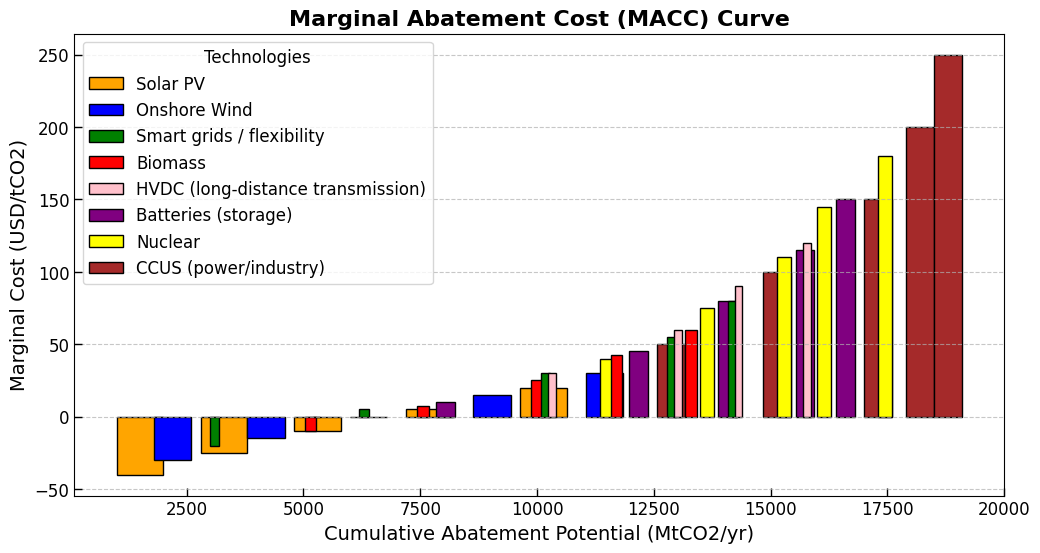

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Sort by cost for MACC and compute cumulative potential
MACC_data = MACC_data.sort_values('marginal_cost_USD_per_tCO2') #sort by cost
MACC_data['cumulative_potential_MtCO2_per_year'] = MACC_data['segment_potential_MtCO2_per_year'].cumsum() #calculate cumulative potential

#Plot MACC curve
plt.figure(figsize=(12,6))

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12})

for _, row in MACC_data.iterrows():
    plt.bar(row['cumulative_potential_MtCO2_per_year'],
            row['marginal_cost_USD_per_tCO2'],
            width=row['segment_potential_MtCO2_per_year'],
            color=row['color'],
            align='edge',
            edgecolor='black'
            )

plt.title('Marginal Abatement Cost (MACC) Curve', fontsize=16, weight='bold')
plt.xlabel('Cumulative Abatement Potential (MtCO2/yr)', fontsize=14)
plt.ylabel('Marginal Cost (USD/tCO2)', fontsize=14)

#Create legend from the colors dictionary
legend_elements = [Patch(facecolor=color, edgecolor='black',label=tech)
                    for tech, color in colors.items()]
plt.legend(handles=legend_elements, title='Technologies')

#Ticks inward
plt.tick_params(axis='both', direction='in', length=6, width=1)

#Add a coarse grid
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.8, alpha=0.7)

#Show plot
plt.show()


#Investment Costs and Levelized Cost of Abatement (LCCA)


Detailed financial parameters for each technology are defined, including:

- **CAPEX**: Capital expenditure per MtCO2.
- **OPEX**: Operating expenditure per year.
- **Lifetime**: The operational lifespan of the technology.
- **Discount Rate**: Used to evaluate the present value of future cash flows.

These parameters are used to calculate the **Annualized CAPEX** and **Discounted OPEX**. From these, the **Levelized Cost of Abatement (LCOA)** is derived, representing the average cost of abating one tonne of CO2 over the project's lifetime.

In [3]:
# Financial parameters dictionary ($ in Millions)
financial_params = {
    'Solar PV': {'CAPEX': 800, 'OPEX': 20, 'lifetime': 25, 'discount_rate': 0.07},
    'Onshore Wind': {'CAPEX': 700, 'OPEX': 15, 'lifetime': 25, 'discount_rate': 0.07},
    'Smart grids / flexibility': {'CAPEX': 500, 'OPEX': 10, 'lifetime': 20, 'discount_rate': 0.07},
    'Biomass': {'CAPEX': 900, 'OPEX': 30, 'lifetime': 25, 'discount_rate': 0.07},
    'HVDC (long-distance transmission)': {'CAPEX': 600, 'OPEX': 5, 'lifetime': 30, 'discount_rate': 0.07},
    'Batteries (storage)': {'CAPEX': 400, 'OPEX': 10, 'lifetime': 15, 'discount_rate': 0.07},
    'Nuclear': {'CAPEX': 5000, 'OPEX': 100, 'lifetime': 40, 'discount_rate': 0.07},
    'CCUS (power/industry)': {'CAPEX': 2000, 'OPEX': 50, 'lifetime': 25, 'discount_rate': 0.07}
}

#Calculate financial parameters
MACC_data['CAPEX_USD_per_MtCO2']= MACC_data['technology'].map(lambda x: financial_params[x]['CAPEX'])
MACC_data['OPEX_USD_per_year']= MACC_data['technology'].map(lambda x: financial_params[x]['OPEX'])
MACC_data['lifetime_years']= MACC_data['technology'].map(lambda x: financial_params[x]['lifetime'])
MACC_data['discount_rate'] = MACC_data['technology'].map(lambda x: financial_params[x]['discount_rate'])


In [4]:
#Discounted OPEX
MACC_data['PV_OPEX_USD_per_MtCO2'] = MACC_data['OPEX_USD_per_year'] * (1 / (1 + MACC_data['discount_rate']) ** MACC_data['lifetime_years'])

#Total (YEARLY) cost is CAPEX + OPEX
MACC_data['total_cost_USD_per_MtCO2_per_year']  = MACC_data['CAPEX_USD_per_MtCO2'] + MACC_data['PV_OPEX_USD_per_MtCO2']

#Levelised Cost of Abatement
MACC_data['LCOA_USD_per_tCO2'] = MACC_data['total_cost_USD_per_MtCO2_per_year'] / (MACC_data['segment_potential_MtCO2_per_year'])


In [5]:
#Data Ordering
MACC_data = MACC_data.sort_values('technology')
MACC_data['cumulative_potential_MtCO2_per_year'] = MACC_data['segment_potential_MtCO2_per_year'].cumsum()

# tech_grouped = MACC_data.groupby('technology').agg(
#     {'segment_potential_MtCO2_per_year' : 'sum',
#      'LCOA_USD_per_tCO2' : 'mean',
#      'color' : 'first'}).reset_index()


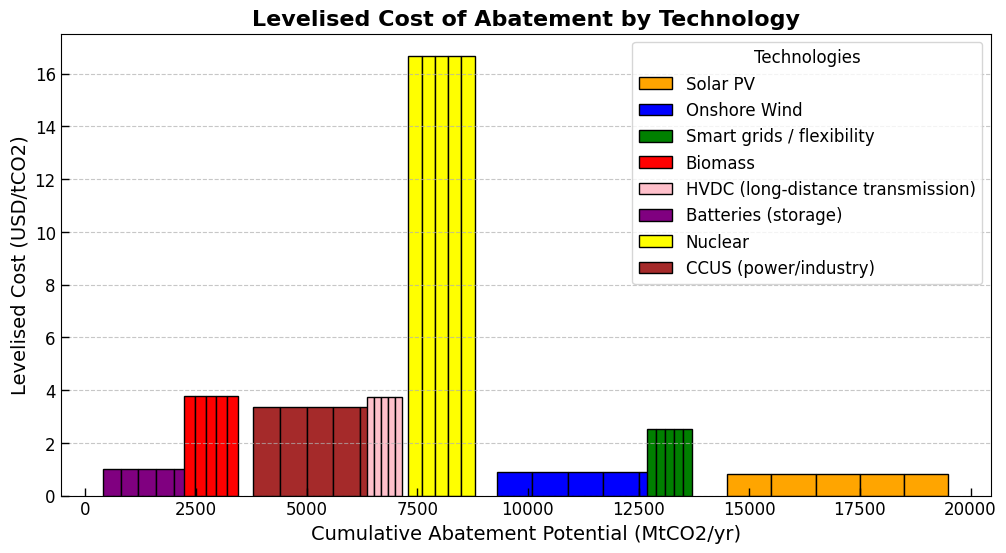

In [6]:
#Plot
plt.figure(figsize=(12,6))

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12})

for _, row in MACC_data.iterrows():
    plt.bar(row['cumulative_potential_MtCO2_per_year'],
            row['LCOA_USD_per_tCO2'],
            width=row['segment_potential_MtCO2_per_year'],
            color=row['color'],
            align='edge',
            edgecolor='black'
            )

plt.title('Levelised Cost of Abatement by Technology', fontsize=16, weight='bold')
plt.xlabel('Cumulative Abatement Potential (MtCO2/yr)', fontsize=14)
plt.ylabel('Levelised Cost (USD/tCO2)', fontsize=14)

#Create legend from the colors dictionary
legend_elements = [Patch(facecolor=color, edgecolor='black',label=tech)
                    for tech, color in colors.items()]
plt.legend(handles=legend_elements, title='Technologies')

#Ticks inward
plt.tick_params(axis='both', direction='in', length=6, width=1)

#Add a coarse grid
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.8, alpha=0.7)

#Show plot
plt.show()

#Investment Returns Timeline


This section analyzes the cash flow of investments over time. By considering annual revenues (driven by carbon prices) and annual costs (OPEX + annualized CAPEX), the project models the cumulative cash flow for each technology. This helps in understanding the timeline for investment returns and profitability.

###Infer Capacity from the Emissions of the plant
The emission factor is based on the technology being displaced, allowing us to estimate how much fossil fuel capacity corresponds to a given amount of emissions abated. This effectively determines the capacity being replaced and is treated as a constant assumption across all technologies when we assume fossil fuels are displaced. Coal has an emission factor of about 1 tCO₂/MWh, while gas is around 0.45 tCO₂/MWh (both taken at the higher end of their ranges). Based on this, we approximate a representative emission factor of 0.5 tCO₂/MWh.


$Capacity\ (\text{MW}) = \frac{\text{Avoided emissions }(\text{tCO}_2/\text{yr})}{\text{Emission factor }(\text{tCO}_2/\text{MWh}) \cdot \text{C.F.} \cdot 8760}$


In [7]:
#Introduce Capacity Factor estimated data
capacity_factors = {
    'Solar PV': 0.18 ,
    'Onshore Wind': 0.32,
    'Smart grids / flexibility': None,
    'Biomass': 0.80 ,
    'HVDC (long-distance transmission)': None,
    'Batteries (storage)': None,
    'Nuclear': 0.90,
    'CCUS (power/industry)': 0.85}

MACC_data['capacity_factor'] = MACC_data['technology'].map(capacity_factors)

#Infer Capacity from Abated Emissions, using the assumptions.
MACC_data['capacity_MW'] = MACC_data['segment_potential_MtCO2_per_year'] * 10**6 / (0.5 * MACC_data['capacity_factor'] * 8760)

**Note:** when looking at capacity, we realise that our abatement input size was that equivalent to a global scale, not an individual solar project. Need to improve or replace input data.


In [8]:
print(MACC_data[['technology', 'capacity_MW','capacity_factor']])

                           technology   capacity_MW  capacity_factor
21                Batteries (storage)           NaN              NaN
35                Batteries (storage)           NaN              NaN
32                Batteries (storage)           NaN              NaN
27                Batteries (storage)           NaN              NaN
12                Batteries (storage)           NaN              NaN
11                            Biomass  6.849315e+04             0.80
20                            Biomass  6.849315e+04             0.80
25                            Biomass  6.849315e+04             0.80
6                             Biomass  6.849315e+04             0.80
15                            Biomass  6.849315e+04             0.80
38              CCUS (power/industry)  1.611604e+05             0.85
39              CCUS (power/industry)  1.611604e+05             0.85
30              CCUS (power/industry)  1.611604e+05             0.85
36              CCUS (power/indust

###Calculate Revenue from Generation

$\text{Revenue} = \text{Capacity} * \text{CF} * 8760 * \text{Electricity Price}$

Price Assumption:
- Conservative: £50 / MWh
- **Mid: £80 / MWh**
- High: £100+ / MWh



In [9]:
#Revenue
MACC_data['revenue_per_year'] = MACC_data['capacity_MW'] * MACC_data['capacity_factor'] * 8760 * 80
MACC_data['revenue_per_year']

,revenue_per_year
21,NaN
35,NaN
32,NaN
27,NaN
12,NaN
11,3.840000e+10
20,3.840000e+10
25,3.840000e+10
6,3.840000e+10
15,3.840000e+10


In [21]:
MACC_data.columns

Index(['technology', 'segment', 'segment_potential_MtCO2_per_year',
       'marginal_cost_USD_per_tCO2', 'cumulative_potential_MtCO2_per_year',
       'color', 'CAPEX_USD_per_MtCO2', 'OPEX_USD_per_year', 'lifetime_years',
       'discount_rate', 'PV_OPEX_USD_per_MtCO2',
       'total_cost_USD_per_MtCO2_per_year', 'LCOA_USD_per_tCO2',
       'capacity_factor', 'capacity_MW', 'revenue_per_year'],
      dtype='object')

###Model Financial Metrics

In [19]:
# Discounting Function
def discounting(object, discount_rate, year):
  factor  = (1 / (1 + discount_rate)) ** year
  return object * factor

In [40]:
#DCF model
import numpy as np
import pandas as pd

# Time horizon (max lifetime across technologies)
max_years = MACC_data['lifetime_years'].max()

# Initialize cumulative cash flow dictionary
discounted_cash_flows = {}
irr_results = {}

for _, row in MACC_data.iterrows():
    tech_name = row['technology']
    lifetime = int(row['lifetime_years'])
    r = row['discount_rate']

    #Upfront CAPEX
    capex_total = row['CAPEX_USD_per_MtCO2'] * row['segment_potential_MtCO2_per_year']

    #Annual revenue and costs
    annual_revenue = row['revenue_per_year']
    annual_opex = row['OPEX_USD_per_year']
    net_cf = annual_revenue - annual_opex

    #Initialize cash flow time series
    cf = np.zeros(max_years)
    cf[0] = -capex_total

    #Year timeline
    for t in range(1, lifetime):
      cf[t] = net_cf #assumes constant revenue and opex

    #Discounted cash flow
    discounted_cf = np.array([discounting(cf[t], r, t) for t in range(len(cf))])

    #Cumulative DCF for payback/ROI timeline
    #Eliminate this to get net yearly cash flows
    cumulative_dcf = np.cumsum(discounted_cf)
    discounted_cash_flows[tech_name] = cumulative_dcf

    #Optional
    #IRR
    # irr = np.irr(cf)
    # irr_results[tech_name] = irr

In [39]:
dcf_df = pd.DataFrame(discounted_cash_flows)
dcf_df = dcf_df.drop(columns=['Batteries (storage)',
                              'HVDC (long-distance transmission)',
                              'Smart grids / flexibility'])
dcf_df = dcf_df.iloc[:25] #keep years 0 to 24

dcf_df

,Biomass,CCUS (power/industry),Nuclear,Onshore Wind,Solar PV
0,-2.160000e+05,-1.200000e+06,-1.500000e+06,-5.600000e+05,-8.000000e+05
1,3.588763e+10,8.971843e+10,4.485831e+10,1.196256e+11,1.495319e+11
2,6.942768e+10,1.735685e+11,8.678337e+10,2.314258e+11,2.892821e+11
3,1.007735e+11,2.519331e+11,1.259657e+11,3.359119e+11,4.198898e+11
4,1.300687e+11,3.251711e+11,1.625846e+11,4.335625e+11,5.419530e+11
5,1.574474e+11,3.936178e+11,1.968080e+11,5.248247e+11,6.560308e+11
6,1.830349e+11,4.575866e+11,2.287924e+11,6.101165e+11,7.626455e+11
7,2.069485e+11,5.173706e+11,2.586844e+11,6.898285e+11,8.622855e+11
8,2.292976e+11,5.732435e+11,2.866208e+11,7.643256e+11,9.554070e+11
9,2.501847e+11,6.254611e+11,3.127296e+11,8.339492e+11,1.042436e+12


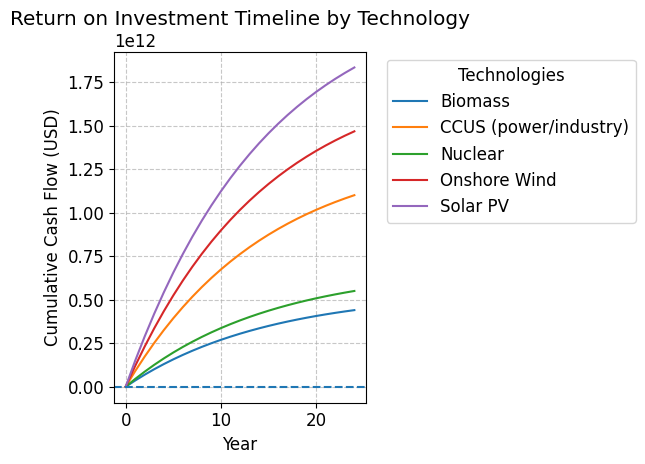

In [41]:
#ROI timeline
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

for column in dcf_df.columns:
    plt.plot(dcf_df.index, dcf_df[column], label=column)

plt.axhline(0, linestyle ='--') #break-even line

plt.xlabel('Year')
plt.ylabel('Cumulative Cash Flow (USD)')
plt.title('Return on Investment Timeline by Technology')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Technologies', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()





In [ ]:
#IRR estimates

#Market Influences


The project considers dynamic market conditions that can influence ROI, such as:

- **Carbon Price Increases**: Simulating scenarios where carbon prices escalate over time.
- **Dynamic CAPEX**: Accounting for technology learning rates, where CAPEX decreases over time (e.g., as seen in solar PV).
- **Policy Incentives**: Evaluating the impact of subsidies on effective CAPEX.

In [ ]:
#Carbon price increases
years = np.arange(0, max_years)
carbon_price_timeline = 50 + 5*years

In [ ]:
#Dynamic CAPEX (cost goes down as technology learning gets better)
capex_learning_rate = 0.95 #getting 5% better every year e.g. solar case


In [ ]:
#Policy incentives: subsidies
CAPEX = MACC_data['CAPEX_USD_per_MtCO2'] * MACC_data['segment_potential_MtCO2_per_year']
subsidy_fraction = 0.25 #25% subsidized
effective_CAPEX = CAPEX * (1 - subsidy_fraction)

Net Cash Flow is:

$$Net CF_t​=(Abatementt​ \cdot Carbon Price_t+Other Revenues)−(OPEX_t​+Annualized CAPEX$$

#Monte Carlo Sensitivity Analysis


A crucial part of the project is the Monte Carlo simulation, which assesses the sensitivity of profitability to uncertainties in key variables. It involves:

- **Sampling Variables**: Randomly sampling CAPEX factors, carbon prices, and discount rates within defined distributions.
- **Vectorized Calculations**: Performing LCOA and revenue calculations for thousands of iterations.
- **Distribution Analysis**: Examining the distribution of LCOA and revenue for each technology segment.
- **Profitability Probability**: Calculating the probability of a technology being profitable (LCOA < 0) and how this probability changes under different carbon price scenarios (low, medium, high).

In [ ]:
MACC_data.head()

,technology,segment,segment_potential_MtCO2_per_year,marginal_cost_USD_per_tCO2,cumulative_potential_MtCO2_per_year,CAPEX_USD_per_MtCO2,OPEX_USD_per_year,lifetime_years,discount_rate,annualized_CAPEX,annual_cost,LCOA_USD_per_tCO2,annual_revenue,LCOA_net_USD_per_tCO2
0,Solar PV,1,1000,-40.0,1000,800,20,25,0.07,68648.413777,88648.413777,88.648414,50000,38.648414
1,Onshore Wind,1,800,-30.0,1800,700,15,25,0.07,48053.889644,60053.889644,75.067362,40000,25.067362
2,Solar PV,2,1000,-25.0,2800,800,20,25,0.07,68648.413777,88648.413777,88.648414,50000,38.648414
3,Smart grids / flexibility,1,200,-20.0,3000,500,10,20,0.07,9439.292574,11439.292574,57.196463,10000,7.196463
4,Onshore Wind,2,800,-15.0,3800,700,15,25,0.07,48053.889644,60053.889644,75.067362,40000,25.067362


In [ ]:
#!pip install caas_jupyter_tools

ERROR: Could not find a version that satisfies the requirement caas_jupyter_tools (from versions: none)
ERROR: No matching distribution found for caas_jupyter_tools


=====Monte Carlo LCOA Results (USD/tCO2)=====
       Solar PV seg1  Onshore Wind seg1  Solar PV seg2  \
count    5000.000000        5000.000000    5000.000000   
mean       19.859555           2.477173      19.859555   
std       118.164134         114.276434     118.164134   
min      -412.223416        -421.509581    -412.223416   
5%       -167.020896        -179.096893    -167.020896   
50%        16.423478           0.325389      16.423478   
95%       216.840824         193.748786     216.840824   
max       459.144372         420.261440     459.144372   

       Smart grids / flexibility seg1  Onshore Wind seg2  Solar PV seg3  \
count                     5000.000000        5000.000000    5000.000000   
mean                       -23.888120           2.477173      19.859555   
std                        107.390604         114.276434     118.164134   
min                       -430.647639        -421.509581    -412.223416   
5%                        -195.143457        -179.096893

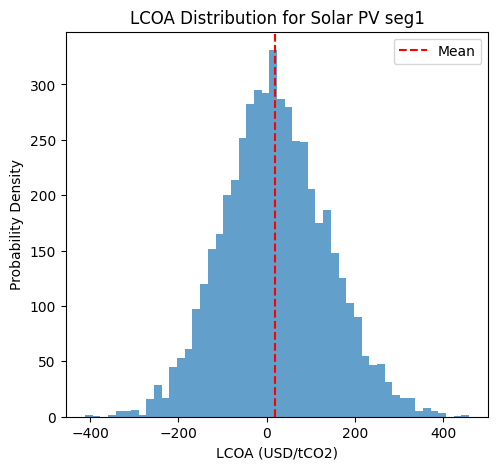

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copy MACC data into numpy arrays for fast math
potentials = MACC_data['segment_potential_MtCO2_per_year'].values
CAPEX_vals = MACC_data['CAPEX_USD_per_MtCO2'].values
OPEX_vals = MACC_data['OPEX_USD_per_year'].values
lifetimes = MACC_data['lifetime_years'].values
tech_names = MACC_data['technology'].values + " seg" + MACC_data['segment'].astype(str).values

#Monte Carlo Setting
n_iter = 5000
results_LCOA = []
results_revenue = []

def annualized_capex(capex, r, n):
  return capex * r * (1+r)**n / (( 1 +r)**n -1)

for i in range(n_iter):
    #sample variables
    capex_factor = np.random.normal(1, 0.2) #+- 20%
    carbon_price = np.random.normal(100, 100) #mean =100 , std 100
    discount_rate = np.random.normal(0.1, 0.1) # mean 10% sd = 10%
    discount_rate = max(discount_rate, 0.01) #avoid negatives ##NOT SURE THIS WORKS HERE

    #Vectorized calculations
    capex_total = CAPEX_vals * potentials * capex_factor
    annualized = annualized_capex(capex_total, discount_rate, lifetimes)
    annual_revenue = carbon_price * potentials
    annual_cost = OPEX_vals * potentials + annualized

    #Store results
    LCOA = (annual_cost - annual_revenue) / potentials
    revenue = annual_revenue

    results_LCOA.append(LCOA)
    results_revenue.append(revenue)

    # iter_data = []

    # for _, row in MACC_data.iterrows():
    #     capex_total = row['CAPEX_USD_per_MtCO2'] * row['segment_potential_MtCO2_per_year'] * capex_factor
    #     annualized = annualized_capex(capex_total, discount_rate, row['lifetime_years'])
    #     annual_revenue = carbon_price * row['segment_potential_MtCO2_per_year']
    #     annual_cost = MACC_data['annual_cost']

    #     LCOA_net = (annual_cost - annual_revenue)/row['segment_potential_MtCO2_per_year']

    #     iter_data.append(LCOA_net)

    # results.append(iter_data)

#Convert result to dataframe
#results_df = pd.DataFrame(results, columns=MACC_data['technology'] + 'seg' + MACC_data['segment'].astype(str))
LCOA_df = pd.DataFrame(results_LCOA, columns=tech_names)
Revenue_df = pd.DataFrame(results_revenue, columns=tech_names)

results_df = LCOA_df
#Summary statistics
print('=====Monte Carlo LCOA Results (USD/tCO2)=====')
print(results_df.describe(percentiles=[0.05, 0.5, 0.95]))
  #summary_stats = results_df.describe(percentiles=[0.05, 0.5, 0.95]).T

#Plot distribution for one example tech
tech_example=results_df.columns[0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(results_df[tech_example], bins=50, density=False, alpha=0.7)
plt.axvline(results_df[tech_example].mean(), color='r', linestyle='--', label='Mean')
plt.title(f'LCOA Distribution for {tech_example}')
plt.xlabel('LCOA (USD/tCO2)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

=====Monte Carlo LCOA Results (USD/tCO2)=====
       Solar PV seg1  Onshore Wind seg1  Solar PV seg2  \
count    5000.000000        5000.000000    5000.000000   
mean    99199.505199       79359.604159   99199.505199   
std    100631.366219       80505.092975  100631.366219   
min   -220468.031616     -176374.425293 -220468.031616   
5%     -65682.507572      -52546.006058  -65682.507572   
50%     98437.610103       78750.088082   98437.610103   
95%    264283.898419      211427.118735  264283.898419   
max    488826.943539      391061.554831  488826.943539   

       Smart grids / flexibility seg1  Onshore Wind seg2  Solar PV seg3  \
count                     5000.000000        5000.000000    5000.000000   
mean                     19839.901040       79359.604159   99199.505199   
std                      20126.273244       80505.092975  100631.366219   
min                     -44093.606323     -176374.425293 -220468.031616   
5%                      -13136.501514      -52546.006058

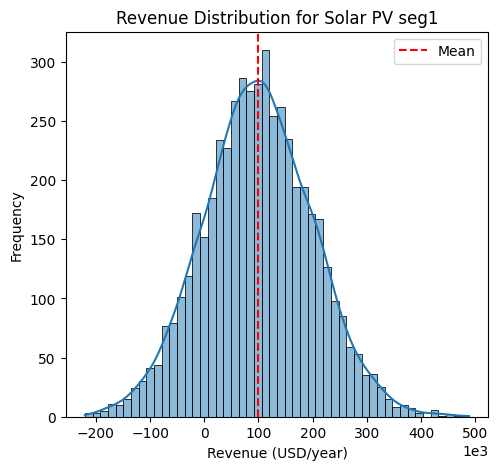

In [ ]:
import seaborn as sns

results_df = Revenue_df
#Summary statistics
print('=====Monte Carlo LCOA Results (USD/tCO2)=====')
print(results_df.describe(percentiles=[0.05, 0.5, 0.95]))
  #summary_stats = results_df.describe(percentiles=[0.05, 0.5, 0.95]).T

#Plot distribution for one example tech
tech_example=results_df.columns[0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(Revenue_df[tech_example], bins = 50, kde=True)
#plt.hist(results_df[tech_example], bins=50, density=False, alpha=0.7)
# plt.xscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3,3)) #scale by 10^3
plt.axvline(results_df[tech_example].mean(), color='r', linestyle='--', label='Mean')
plt.title(f'Revenue Distribution for {tech_example}')
plt.xlabel('Revenue (USD/year)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

<Axes: xlabel='Solar PV seg1', ylabel='Count'>

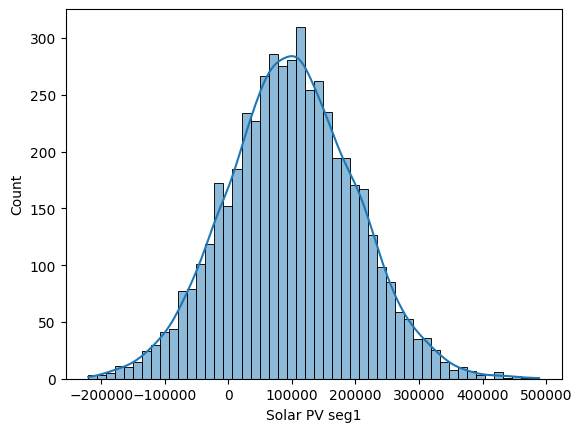

In [ ]:
import seaborn as sns
sns.histplot(Revenue_df[tech_example], bins = 50, kde=True)


In [ ]:
MACC_data['annualized_CAPEX']

,annualized_CAPEX
0,68648.413777
1,48053.889644
2,68648.413777
3,9439.292574
4,48053.889644
5,68648.413777
6,18535.071720
7,7736.294737
8,48053.889644
9,9439.292574


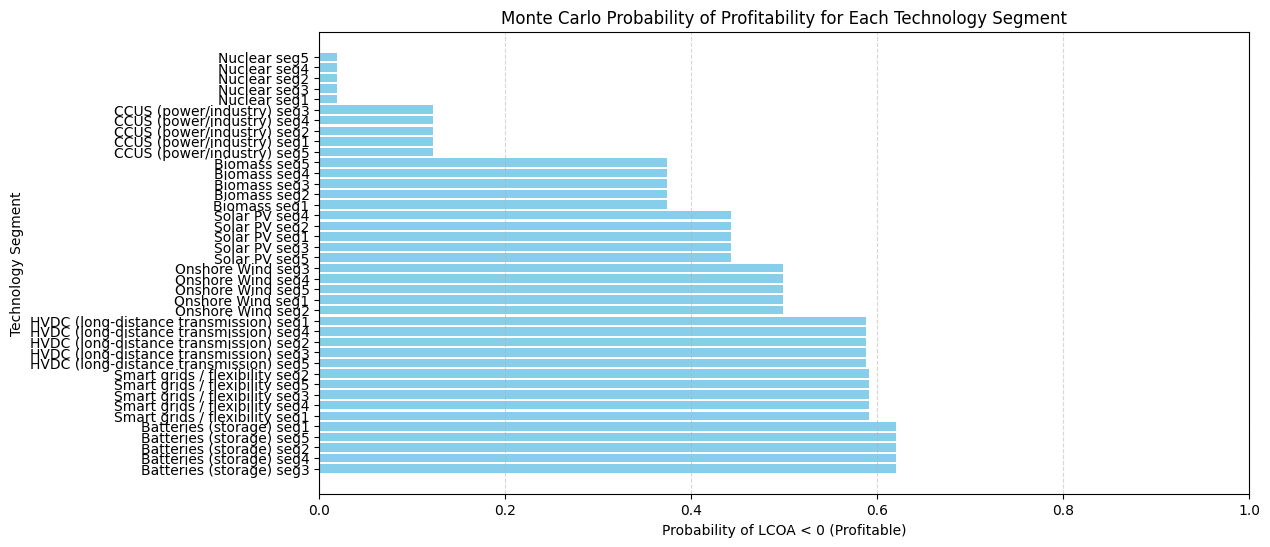

In [ ]:
#Chance of profitability - probability of LCOA<0 for each tech segment

#Calculate fraction of entries with LCOA<0 for each segment
profit_prob = (LCOA_df <0).mean(axis=0)

#Turn into dataframe
profit_prob_df = pd.DataFrame({
    'Tech Segment': profit_prob.index,
    'Profit_Prob': profit_prob.values
}).sort_values(by='Profit_Prob', ascending=False)

#profit_prob_df

#Visualise Profitability

plt.figure(figsize=(12,6))
plt.barh(profit_prob_df['Tech Segment'], profit_prob_df['Profit_Prob'], color='skyblue')
plt.xlabel("Probability of LCOA < 0 (Profitable)")
plt.ylabel("Technology Segment")
plt.title("Monte Carlo Probability of Profitability for Each Technology Segment")
plt.xlim(0,1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()



In [ ]:
#Dependence on market conditions
#Split simuations into low, medium, high carbon price
carbon_price_samples = np.random.normal(100, 100, n_iter)

low_mask=(carbon_price_samples<50)
med_mask=(carbon_price_samples >=50) & (carbon_price_samples <=100)
high_mask=carbon_price_samples >100

#Calculate LCOA <0 probability in each senario for each tech
tech_example = LCOA_df.columns[0] ###

low_prob = (LCOA_df[tech_example][low_mask] < 0).mean()
med_prob = (LCOA_df[tech_example][med_mask] < 0).mean()
high_prob = (LCOA_df[tech_example][high_mask] < 0).mean()

print(f"{tech_example} profitability probabilities:")
print(f"Low carbon price (<40 USD/tCO2): {low_prob:.2f}")
print(f"Medium carbon price (40-60 USD/tCO2): {med_prob:.2f}")
print(f"High carbon price (>60 USD/tCO2): {high_prob:.2f}")

Solar PV seg1 profitability probabilities:
Low carbon price (<40 USD/tCO2): 0.44
Medium carbon price (40-60 USD/tCO2): 0.44
High carbon price (>60 USD/tCO2): 0.45


In [ ]:
import numpy as np
import pandas as pd

# Assume you have stored carbon price samples from Monte Carlo
# If not, resample here:
n_iter = LCOA_df.shape[0]
carbon_price_samples = np.random.normal(100, 100, n_iter)

# Define scenarios
low_mask = carbon_price_samples < 50
med_mask = (carbon_price_samples >= 50) & (carbon_price_samples <= 100)
high_mask = carbon_price_samples > 100

# Prepare table
tech_list = LCOA_df.columns[:10]  # first 10 technologies
profit_table = []

for tech in tech_list:
    low_prob = (LCOA_df[tech][low_mask] < 0).mean()
    med_prob = (LCOA_df[tech][med_mask] < 0).mean()
    high_prob = (LCOA_df[tech][high_mask] < 0).mean()

    profit_table.append({
        'Technology_Segment': tech,
        'LowCarbonPrice(<40)': low_prob,
        'MediumCarbonPrice(40-60)': med_prob,
        'HighCarbonPrice(>60)': high_prob
    })

profit_df = pd.DataFrame(profit_table)

# Display table
profit_df


,Technology_Segment,LowCarbonPrice(<40),MediumCarbonPrice(40-60),HighCarbonPrice(>60)
0,Solar PV seg1,0.435847,0.437186,0.448456
1,Onshore Wind seg1,0.496693,0.487437,0.504613
2,Solar PV seg2,0.435847,0.437186,0.448456
3,Smart grids / flexibility seg1,0.587963,0.588945,0.593662
4,Onshore Wind seg2,0.496693,0.487437,0.504613
5,Solar PV seg3,0.435847,0.437186,0.448456
6,Biomass seg1,0.374339,0.372864,0.375050
7,HVDC (long-distance transmission) seg1,0.584656,0.582915,0.590854
8,Onshore Wind seg3,0.496693,0.487437,0.504613
9,Smart grids / flexibility seg2,0.587963,0.588945,0.593662
